In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.linalg import toeplitz, solve

# --- PARAMETERS ---
dt = 0.002           # Sampling interval in seconds (2 ms)
t_max = 1.0          # Total trace duration in seconds
f_peak = 30.0        # Peak frequency of the Ricker wavelet in Hz
noise_level = 0.05   # Amplitude of random noise added to the trace
num_spikes = 15      # Number of random spikes in the reflectivity series
seed = 42            # Random seed for reproducibility
# ------------------

# Generate Time Array
t = np.arange(0, t_max, dt)
n_samples = len(t)

# 1. Generate Ricker Wavelet
def ricker_wavelet(time_array, f):
    return (1.0 - 2.0 * (np.pi**2) * (f**2) * (time_array**2)) * np.exp(-(np.pi**2) * (f**2) * (time_array**2))

tw = np.arange(-0.1, 0.1, dt)
wavelet = ricker_wavelet(tw, f_peak)

# 2. Generate Random Spike Train (Reflectivity)
np.random.seed(seed)
r_t = np.zeros(n_samples)
spike_indices = np.random.randint(0, n_samples, num_spikes)
r_t[spike_indices] = np.random.randn(num_spikes)

# 3. Convolve to create synthetic trace and add noise
x_t = np.convolve(r_t, wavelet, mode='same') 
x_t += noise_level * np.random.randn(n_samples)

print(f"Step 1 Complete: Generated 1D NumPy array x(t) with {n_samples} samples.")

Step 1 Complete: Generated 1D NumPy array x(t) with 500 samples.


In [2]:
# --- PARAMETERS ---
# Uses 'x_t', 'dt', and 'n_samples' from Cell 1
# ------------------

# Calculate the Discrete Fourier Transform
X_f = fft(x_t)

# Compute corresponding frequency bins
freqs = fftfreq(n_samples, d=dt)

print("Step 2 Complete: Transformed trace to frequency domain X(f).")

Step 2 Complete: Transformed trace to frequency domain X(f).


In [3]:
# --- PARAMETERS ---
# Ormsby Filter Frequencies (in Hz): low-cut, low-pass, high-pass, high-cut
f1, f2, f3, f4 = 10, 20, 60, 80 
# ------------------

# Create the filter response array H(f)
abs_freqs = np.abs(freqs)
H_f = np.zeros_like(abs_freqs, dtype=float)

# Vectorized construction of the Ormsby taper
mask_low_taper = (abs_freqs > f1) & (abs_freqs < f2)
H_f[mask_low_taper] = (abs_freqs[mask_low_taper] - f1) / (f2 - f1)

mask_pass = (abs_freqs >= f2) & (abs_freqs <= f3)
H_f[mask_pass] = 1.0

mask_high_taper = (abs_freqs > f3) & (abs_freqs < f4)
H_f[mask_high_taper] = (f4 - abs_freqs[mask_high_taper]) / (f4 - f3)

# Apply the filter to the frequency spectrum
Y_f = X_f * H_f

print(f"Step 3 Complete: Applied {f1}-{f2}-{f3}-{f4} Hz Ormsby bandpass filter.")

Step 3 Complete: Applied 10-20-60-80 Hz Ormsby bandpass filter.


In [4]:
# --- PARAMETERS ---
# Uses 'Y_f' from Cell 3
# ------------------

# Bring the cleaned frequency data back to the time domain
# We take the real part to discard any minor imaginary rounding errors
y_t = ifft(Y_f).real

print("Step 4 Complete: Transformed filtered data back to time domain y(t).")

Step 4 Complete: Transformed filtered data back to time domain y(t).


In [5]:
# --- PARAMETERS ---
filter_length = 60  # Number of coefficients (taps) in the Wiener filter
epsilon = 0.01      # Pre-whitening factor (adds stability to matrix inversion)
# ------------------

# 1. Calculate autocorrelation of y(t)
autocorr = np.correlate(y_t, y_t, mode='full')
mid_idx = len(autocorr) // 2

# Extract the positive lags for the Toeplitz matrix
r_yy = autocorr[mid_idx : mid_idx + filter_length]

# Add pre-whitening to the zero-lag (diagonal of the matrix) to prevent singularity
r_yy[0] *= (1.0 + epsilon)

# 2. Build Toeplitz matrix from autocorrelation values
R_matrix = toeplitz(r_yy)

# 3. Define desired output as cross-correlation vector (spike at lag zero)
# For a zero-delay perfect spike, the cross-correlation vector is [1, 0, 0, ...]
g = np.zeros(filter_length)
g[0] = 1.0 

# 4. Solve Wiener-Hopf normal equations for filter coefficients f(t)
f_t = solve(R_matrix, g)

# 5. Convolve filter with the filtered trace to get estimated reflectivity
r_est = np.convolve(y_t, f_t, mode='same')

print(f"Step 5 Complete: Applied Wiener Spiking Deconvolution with filter length {filter_length}.")

Step 5 Complete: Applied Wiener Spiking Deconvolution with filter length 60.


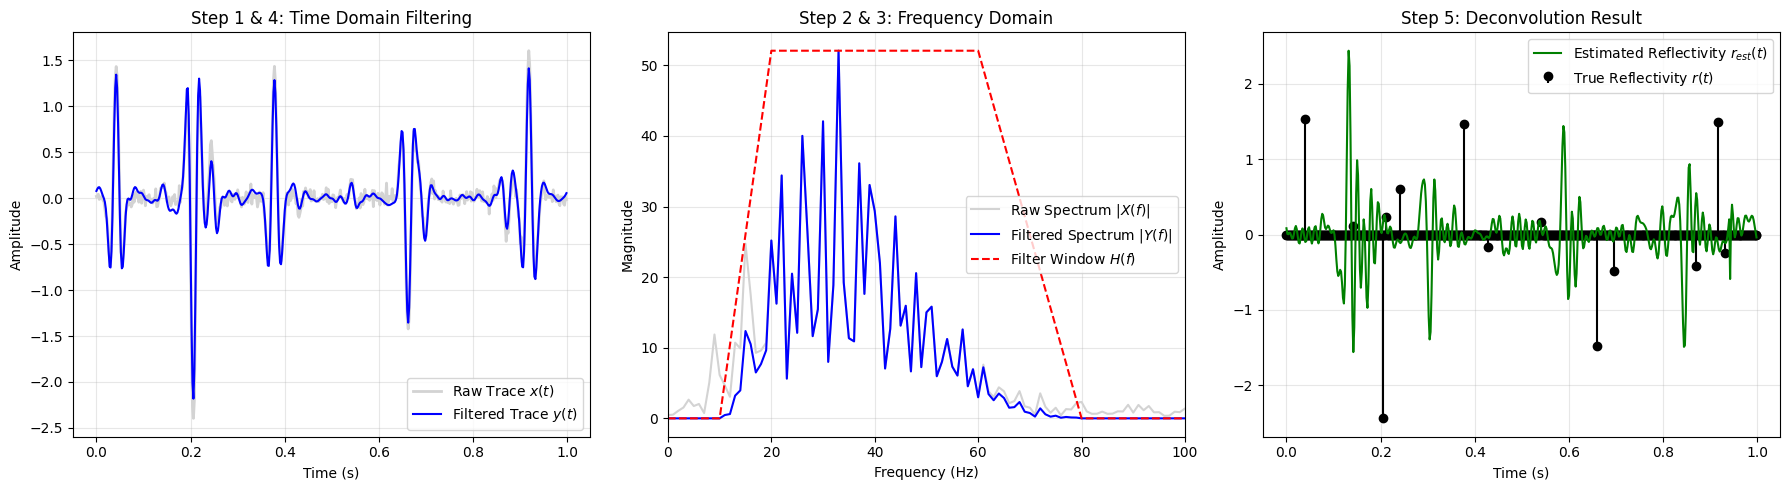

In [6]:
# --- PARAMETERS ---
plot_xlim = (0, 100) # Limits for the frequency axis (Hz)
# ------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Raw Trace vs Filtered Trace
axes[0].plot(t, x_t, label='Raw Trace $x(t)$', color='lightgray', linewidth=2)
axes[0].plot(t, y_t, label='Filtered Trace $y(t)$', color='blue', linewidth=1.5)
axes[0].set_title('Step 1 & 4: Time Domain Filtering')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Frequency Spectrum and Filter Window
pos_mask = freqs >= 0 # Only plot positive frequencies
axes[1].plot(freqs[pos_mask], np.abs(X_f)[pos_mask], label='Raw Spectrum $|X(f)|$', color='lightgray')
axes[1].plot(freqs[pos_mask], np.abs(Y_f)[pos_mask], label='Filtered Spectrum $|Y(f)|$', color='blue')
# Scale the filter window up to the max amplitude for visual overlay
scaled_Hf = H_f[pos_mask] * np.max(np.abs(X_f))
axes[1].plot(freqs[pos_mask], scaled_Hf, label='Filter Window $H(f)$', color='red', linestyle='--')
axes[1].set_title('Step 2 & 3: Frequency Domain')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude')
axes[1].set_xlim(plot_xlim)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Deconvolution Result
# Normalize the estimated reflectivity so it scales visually with the true reflectivity
r_est_norm = (r_est / np.max(np.abs(r_est))) * np.max(np.abs(r_t))

# Plot true spikes as stems for clarity
axes[2].stem(t, r_t, linefmt='k-', markerfmt='ko', basefmt=" ", label='True Reflectivity $r(t)$')
axes[2].plot(t, r_est_norm, label='Estimated Reflectivity $r_{est}(t)$', color='green', linewidth=1.5)
axes[2].set_title('Step 5: Deconvolution Result')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('Amplitude')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()